In [1]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from scripts.data_reader import load_and_prepare_time_series_data
from scripts.trainer import Trainer
from models.lstm import LSTMModel

In [2]:
data_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

# Safely unpack the data reader results regardless of which version you have
results = load_and_prepare_time_series_data(
    filepath_or_url=data_url,
    target_column="new_confirmed",
    date_column="date",
    seq_length=14,
    batch_size=32,
    train_split=0.8,
    fill_missing=True
)

train_loader, val_loader, val_dataset, scaler = results

Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared Training batches: 25 | Validation batches: 6


In [3]:
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1)   
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [4]:
trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device="cpu"
    )
trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000)

Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete!


([0.015350709142579978,
  0.011882799933425087,
  0.007433325567601157,
  0.003980204243940758,
  0.003886352918364567,
  0.003265163818120497,
  0.0034433739202379566,
  0.0035460870371829805,
  0.0030162585412923026,
  0.003008074568408592,
  0.002903577308098673,
  0.002806254041517048,
  0.002680932627727486,
  0.003082921161079315,
  0.0028356086813777705,
  0.002682994736614697,
  0.003143868329192591,
  0.002667194621991797,
  0.002705414321005421,
  0.002905599280559173,
  0.00277513758728884,
  0.0027274580766353516,
  0.0025243073795230193,
  0.0024815850864538017,
  0.002432743803597089,
  0.002644006272301779,
  0.002457770789422186,
  0.0023469566723695718,
  0.002660535189372806,
  0.002448651625997456,
  0.0027314133591684188,
  0.002571189595604253,
  0.0025382444478276936,
  0.0023412645764075515,
  0.002371942601106812,
  0.002266745658826016,
  0.002467215524454886,
  0.0023408441254893046,
  0.002405078044839941,
  0.002389779927299997,
  0.0024508650893549574,
  0.

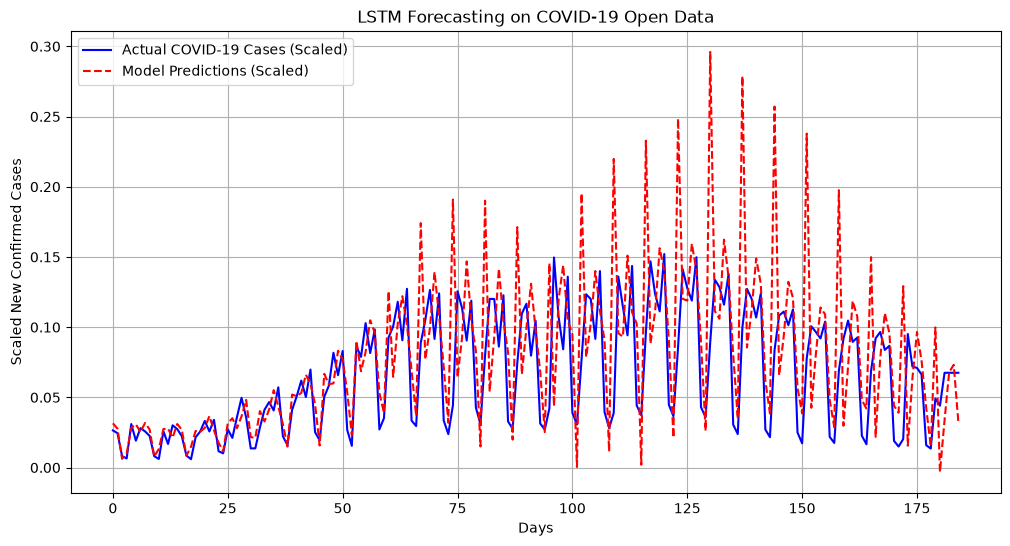

In [6]:
model.eval()
    
actuals = []
predictions = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(trainer.device)
        preds = model(batch_x)
        
        actuals.extend(batch_y.cpu().numpy().flatten())
        predictions.extend(preds.cpu().numpy().flatten())
        
# Plotting the validation data
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual COVID-19 Cases (Scaled)", color="blue")
plt.plot(predictions, label="Model Predictions (Scaled)", color="red", linestyle="--")
plt.title("LSTM Forecasting on COVID-19 Open Data")
plt.xlabel("Days")
plt.ylabel("Scaled New Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()